# Dataset Generation
---

In this notebook we will show the generation of surrogate networks using the **LETN** method. Moreover, there will be control variable to use its extensions, i.e., CLETN (for when the metadata is not available) and DLETN (for the use of dynamic communities)

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from itertools import count

from tqdm import tqdm

import construction as cs
from LETN import count_LETN, build_LETN, get_LETNS
from LETNgen import generate_seed_graphs, generate_graph_g2, get_dict

%load_ext autoreload
%autoreload 2

# 0 Utility Functions

These are some utility functions to build the graphs, modified w.r.t. the `construction.py` version.

In [2]:
def get_number_of_interactions(graphs):
    nb_inter = []
    for g in graphs:
        nb_inter.append(len(g.edges()))
    return nb_inter
    
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [3]:
# Modified version of below to only build with the daily graphs
def build_weighted_day(graphs):
    edges = dict()
    for ind in range(0, len(graphs)):
        g1 = graphs[ind]
        for edge in list(g1.edges()):
            if edge in edges:
                edges[edge] +=1
            else:
                edges[edge] = 1
    g = nx.Graph()
    for k,v in edges.items():
        g.add_edge(k[0],k[1],weight=v)
    
    return g

In [4]:
def build_weighted_graph(file_name):
    data_in = cs.load_data("SocioPatterns/" + file_name + ".dat")
    graphs = cs.build_graphs(data_in, gap=19)
    edges = dict()
    for ind in range(0, len(graphs)):
        g1 = graphs[ind]
        for edge in list(g1.edges()):
            if edge in edges:
                edges[edge] +=1
            else:
                edges[edge] = 1
    g = nx.Graph()
    for k,v in edges.items():
        g.add_edge(k[0],k[1],weight=v)
    
    return g

def search_partition(g):
    v = []
    res_list = np.arange(0.1,2,0.2)
    good_seed = 0
    seeds = []


    for i in res_list:
        tmp = 0
        for s in [10,20,30,40,50]:
            partitions = list(nx.community.louvain_communities(g,weight="weight",resolution=i,seed=s))
            mod = nx.community.modularity(g,partitions)
            if mod > tmp:
                tmp = mod
                good_seed = s
                
        seeds.append(good_seed)
        v.append(tmp)
        

    resolution = res_list[np.argmax(v)]
    correct_seed = seeds[np.argmax(v)]
    partitions = list(nx.community.louvain_communities(g,weight="weight",resolution=resolution,seed=correct_seed))
    
    print("modulatity:\t",np.max(v))
    print("nb. parti.:\t",len(partitions))
    return partitions

def get_labels(partitions):
    lab = dict()
    label = 'A'

    for s in partitions:
        for i in s:
            lab[i] = str(label)
        
        label = chr(ord(label) + 1)
        
    return lab

In [5]:
def my_plot(Gori, Ggen):
    pos = nx.spring_layout(Gori)

    fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(10,5))
    nx.draw_networkx(Gori,pos,edge_color=nx.get_edge_attributes(Gori,"weight").values(),
                     edge_cmap=plt.cm.Greys,
                     with_labels=False,
                     node_size=10,ax=ax1)
    
    groups = set(nx.get_node_attributes(Gori,'label').values())
    mapping = dict(zip(sorted(groups),count()))
    nodes = Gori.nodes()
    colors = [mapping[Gori.nodes[n]['label']] for n in nodes]
    
    nc = nx.draw_networkx_nodes(Gori, pos, nodelist=nodes, node_color=colors, node_size=20, cmap=plt.cm.tab10,ax=ax1)
    ax1.set_title("Original")

    nx.draw_networkx(Ggen,pos,edge_color=nx.get_edge_attributes(Ggen,"weight").values(),
                     edge_cmap=plt.cm.Greys,
                     with_labels=False,
                     node_size=10,ax=ax2)
    groups = set(nx.get_node_attributes(Ggen,'label').values())
    mapping = dict(zip(sorted(groups),count()))
    nodes = Ggen.nodes()
    colors = [mapping[Ggen.nodes[n]['label']] for n in nodes]
    nc = nx.draw_networkx_nodes(Ggen, pos, nodelist=nodes, node_color=colors, node_size=20, cmap=plt.cm.tab10,ax=ax2)
    ax2.set_title("Generated")
    
    
def my_plot2(graphs, tg):
    w = 10
    nb_inter = get_number_of_interactions(graphs)
    smooth_nb_int = moving_average(nb_inter, w)

    plt.figure(figsize=(18,3))
    plt.plot(smooth_nb_int, color="blue", label="Original")
    plt.plot(moving_average(get_number_of_interactions(tg), w), color="red", label="LETN")
    plt.xlabel("Time (Snapshots)")
    plt.ylabel("Interactions")

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

In [6]:
def build_weighted_graph_labels(tg, labels):
    G = nx.Graph()

    for n,l in labels.items():
        G.add_node(n,label=l)

    for g in tg:
        for u,v in g.edges():

            if u > v:
                t = v
                v = u
                u = t
            if G.has_edge(u,v):
                w = G.edges()[(u,v)]["weight"]
                G.edges()[(u,v)]["weight"] = w + 1
            else:
                G.add_edge(u,v)
                
                G.edges()[(u,v)]["weight"] = 1
    return G

# 1 Model Parameters

Here we define the model parameters:
* `GAP` is different for `build_weighted_graph` and when the graph if built due to some inner workings
* `K` is the "length of the signature", i.e., how many consecutive snapshots are used to construct the LETNS for each ego node
* `ALPHA` fraction of the edges to keep in the final validation step when generating a new snapshot
* `local_split` number of seconds for the local split, i.e., how much time each of the dictionaries counting the LETNS cover (usually hours, so each dictionary corresponds to an hour of a day)
* `global_split` number of seconds to group local splits (i.e., after one day they will "reset", meaning that the dictionary of 9AM will count LETNS in the same hour across all the days in the measurement period)

In [7]:
# Temporal GAP (seconds included in same snapshot-1)
GAP = 299

# "Length of signature"
K = 2

# Fraction of edges to keep in final validation step
ALPHA = 0.5

# SPLITS for the snapshots (sec)
local_split = 60*60*1 # 1 hour
global_split = 60*60*24 # 1 day

Then we set the parameters for which kind of algorithm we want to use:
* `letn` whether we want to use the LETN or base ETN algorithm (ETN doesn't work at the moment, please refer to the original repository)
* `communities` whether we want to use the original metadata or if we want to run community detection on the aggregated graph to assign new labels to the nodes)
* `dynamic` whether we want to assign node labels dynamically (only works with both `letn=True` and `communities=True`)

In [8]:
##################
# METHOD CHOICE
##################
letn = True # Leave as True
communities = True

# Dynamic Communities (put true with letn and communities)
dynamic = True

# 2 Data

These are the possible datasets included in the repository. Each of them has metadata associated (`{dataset}_meta.dat` files).

In [9]:
####################
# POSSIBLE DATASETS
####################
datasets = ["HS11", "HS12", "HS13", "hospital", "InVS13", "InVS15", "primaryschool"]

Here we read the data, and depending on the algorithm/extension we chose, load the metadata or find it through community detection.

In [10]:
#################
# READ DATA
#################
file_name = "primaryschool"

data_in = cs.load_data(f"SocioPatterns/{file_name}.dat")
metadata = f"SocioPatterns/{file_name}_meta.dat" # Comment if you don't have metadata, and use communities=True

In [11]:
# If we use letn and need communities we need to get labels from the clustering algorithm
# If we use only letn it means we'll use the metadata we have (load it immediately)
# If we don't even use letn should be ETN (DOESN'T WORK)
if letn and communities:
    w_g = build_weighted_graph(file_name)
    partitions = search_partition(w_g)
    labels = get_labels(partitions)
    metadata = labels
elif letn:
    metadata = cs.load_metadata(metadata)
elif not letn:
    metadata = None

modulatity:	 0.6727315240880087
nb. parti.:	 6


In [12]:
graphs = cs.build_graphs(data_in, gap=GAP, with_labels=letn, meta_path=metadata)
print(len(graphs))

390


# 3 LETNS Counting

In this part we will form the LETNS and the count dictionaries

In [13]:
# Determine the correct splits given the gap of the snapshots
local_split = int(local_split/(GAP+1))
global_split = int(global_split/(GAP+1))

Create a list of the daily graphs (depends on `global_split`). Then, populate them with the graphs per each hour (depends on `local_split`). The list will be of length 24 and each index will contain all the graphs of that specific hour

In [14]:
daily_graphs = []

for i in range(int(global_split/local_split)):
    daily_graphs.append([])
    
hour = 0
c = 1

for i in range(len(graphs)):
    g = graphs[i]
    
    # If in the same hour append the graph
    if i < local_split*c:
        daily_graphs[hour].append(g)
    # Else go next hour
    else:
        c = c + 1
        
        if hour == len(daily_graphs)-1:
            hour = 0
        else:
            hour = hour + 1
            
        daily_graphs[hour].append(g)
        
len(daily_graphs)

24

Once we have the daily graphs, we can actually go through the local splits, combine those graphs and change the labels. with the dynamic ones (if `dynamic=True`).

When there are no interactions, the day graph could actually be empty, so we'll assign the first partition we discovered, as it doesn't matter given that all the original nodes are disconnected.

In [15]:
if dynamic:
    # Transform metadata into a list
    meta_default = metadata
    metadata = []

    # Build the metadata for every local split
    for day in daily_graphs:

        g_tmp = build_weighted_day(day)
        
        # Handle when there are no interactions        
        if len(g_tmp.edges) == 0:
            metadata.append(meta_default)
        else:
            partitions = search_partition(g_tmp)
            labels = get_labels(partitions)
            metadata.append(labels)

            # All the others in the same community?
            next = chr(ord(max(labels.values())) + 1)
            
            # Fill metadata for new nodes
            for n in w_g.nodes():
                if n not in labels:
                    labels[n] = next 
    
            for d in day:
                nx.set_node_attributes(d, labels, 'label')

modulatity:	 0.8603626763607909
nb. parti.:	 8
modulatity:	 0.7637084939502967
nb. parti.:	 8
modulatity:	 0.8003270350073812
nb. parti.:	 9
modulatity:	 0.49887367054751985
nb. parti.:	 5
modulatity:	 0.4078454504291258
nb. parti.:	 5
modulatity:	 0.552891035918857
nb. parti.:	 6
modulatity:	 0.8533311339241579
nb. parti.:	 10
modulatity:	 0.7056625178347643
nb. parti.:	 10
modulatity:	 0.8648589115030626
nb. parti.:	 10
modulatity:	 0.8905129431049794
nb. parti.:	 15


Here we count the LETNS, i.e., Labelled Egocentric Temporal Network Signature. We'll have a dictionary for each local split

In [16]:
LETNSs = []
dizs = []

for i in range(int(global_split/local_split)):
    # Form LETNS and order them (each hour)
    # This metadata will have to be metadata[i] in case of dynamic labels
    if dynamic:
        LETNS = count_LETN(daily_graphs[i], K, meta=metadata[i], pos_end=-1)
    else:
        LETNS = count_LETN(daily_graphs[i], K, meta=metadata, pos_end=-1)
    
    LETNS = {k: v for k, v in sorted(LETNS.items(), reverse=True, key=lambda item: item[1])}
    
    LETNSs.append(LETNS)

    # Handle dynamic metadata and form dictionaries
    if dynamic:
        diz = get_dict(LETNS, K, meta=metadata[i])
    else:
        diz = get_dict(LETNS, K, meta=metadata)
    dizs.append(diz)

    print("Hour: ", i)

Hour:  0
Hour:  1
Hour:  2
Hour:  3
Hour:  4
Hour:  5
Hour:  6
Hour:  7
Hour:  8
Hour:  9
Hour:  10
Hour:  11
Hour:  12
Hour:  13
Hour:  14
Hour:  15
Hour:  16
Hour:  17
Hour:  18
Hour:  19
Hour:  20
Hour:  21
Hour:  22
Hour:  23


In [17]:
# Print one dictionary (one signature of one hour) as example
list(dizs[0].items())[0]

('0100',
 [['0b0100',
   '0b0100000000000100',
   '0b0100000000000100000000000100',
   '0b0100000000000100000000000100000000000100',
   '0b0100000000000100000000000100000000000100000000000100000000000100',
   '0b0100000000000100000000000100000000000100000000000100',
   '0b0100000000000100000000000100000000000100000000000100000000000100000000000100000000000100'],
  [0.7774480712166172,
   0.09198813056379822,
   0.06231454005934718,
   0.04154302670623145,
   0.017804154302670624,
   0.005934718100890208,
   0.002967359050445104]])

# 4 Graph Generation

Generate graphs starting from graph seeds (i.e., K number of snapshots as seeds right). Change the following to customize the generation:
* `generations_number` how many graphs we want to generate
* `nb_snapshots` how many snapshot we want each graph to have
* `verbose` controls whether you want to print a progress of the generation of a network

In [18]:
generations_number = 5 # number of temporal networks to generate
nb_snapshots = len(graphs) # number of snapshots to generate for each temporal network
verbose = True # if you want to print the progress of the generation of one network

for ii in range(generations_number):

    g0 = graphs[0]

    if dynamic:
        graph_seed = generate_seed_graphs(g0, graphs[0:2], K, ALPHA, meta=metadata[0])
    else:
        graph_seed = generate_seed_graphs(g0, graphs[0:2], K, ALPHA, meta=metadata)

    c =  1
    hour = 0 
    nodes = list(graph_seed[0].nodes())
    tg = graph_seed

    if verbose:
        check = tqdm(range(nb_snapshots - K))
    else:
        check = range(nb_snapshots - K)
    
    for i in check:
        if i < local_split*c:
            pos = hour
        else:
            c = c + 1
            if hour == len(daily_graphs) - 1:
                hour = 0
            else:
                hour = hour + 1
            pos = hour
        
        diz = dizs[pos]
        
        graphs_in = tg[i:i+K]

        if dynamic:
            g_new = generate_graph_g2(nodes, graphs_in, diz, K, ALPHA, meta=metadata[hour])
        else:
            g_new = generate_graph_g2(nodes, graphs_in, diz, K, ALPHA, meta=metadata)
        tg.append(g_new)

    
    new_temporal_graph_name = file_name 
    if dynamic:
        new_temporal_graph_name += "_DYN_LETN"
    elif communities == True:
        new_temporal_graph_name += "_COMM_LETN"
    elif not letn:
        new_temporal_graph_name += "_ETN"
    else:
        new_temporal_graph_name += "_LETN"

    print(f"{new_temporal_graph_name} generated graph {ii+1}")

    edge_list = []
    c = 0 
    gap = 300         # Different in the generation from earlier
    nodes = set()
    for i in tg:
        edges = list(i.edges())
        for a,b in edges:
            edge_list.append([c*gap, a, b])
            nodes.add(a)
            nodes.add(b)
        c = c + 1
    
    orig_nod = set(tg[0].nodes())
    diff = orig_nod.difference(nodes)
    for i in diff:
        edge_list.append([c*gap,i,i])
    df_edge_list = pd.DataFrame(edge_list,columns=["t","a","b"])

    directory = f"Generated/{file_name}/"
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    df_edge_list.to_csv(f"{directory}{new_temporal_graph_name}_{str(ii)}.dat", sep=" ", index=False, header=False)

100%|████████████████████████████████████████████████████████████████████████████████| 388/388 [00:44<00:00,  8.72it/s]


primaryschool_DYN_LETN generated graph 1


100%|████████████████████████████████████████████████████████████████████████████████| 388/388 [00:42<00:00,  9.08it/s]


primaryschool_DYN_LETN generated graph 2


100%|████████████████████████████████████████████████████████████████████████████████| 388/388 [00:42<00:00,  9.11it/s]


primaryschool_DYN_LETN generated graph 3


100%|████████████████████████████████████████████████████████████████████████████████| 388/388 [00:42<00:00,  9.05it/s]


primaryschool_DYN_LETN generated graph 4


100%|████████████████████████████████████████████████████████████████████████████████| 388/388 [00:42<00:00,  9.09it/s]


primaryschool_DYN_LETN generated graph 5


# 5 Plots

A couple of simple plots, comparing the last of the generated graphs and the original one. For this we use the original metadata.

The first plot shows the actual aggregated network with nodes colored depending on their class, while the second shows the number of interactions over time (over the snapshots).

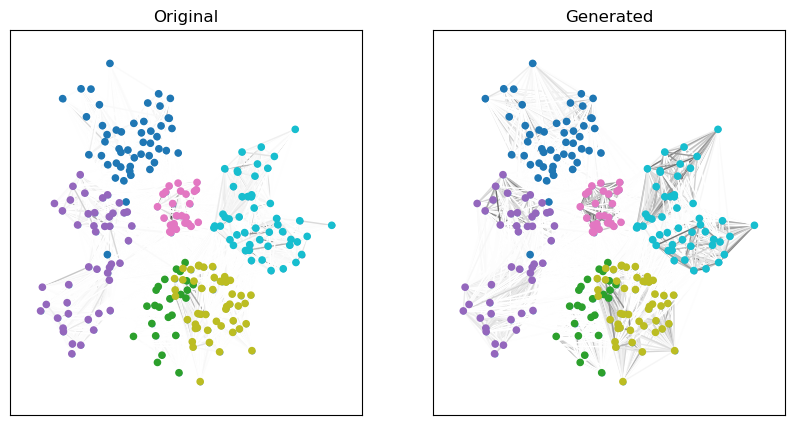

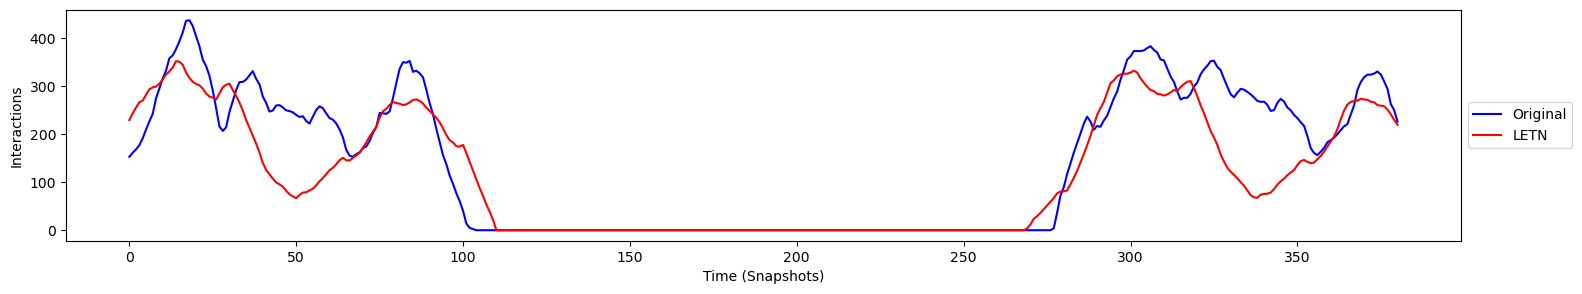

In [19]:
# Plot graphs and interactions
Gw_ori = build_weighted_graph_labels(graphs,meta_default)
Gw_gen = build_weighted_graph_labels(tg,meta_default)
my_plot(Gw_ori,Gw_gen)
my_plot2(graphs,tg)